In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from xgboost import XGBRegressor
import math

# 1. Veri Setini Yükleme
try:
    df = pd.read_csv('df4_final_preparation.csv')
    print("Veri seti başarıyla yüklendi.")
    print(f"Veri setinin boyutu: {df.shape}")
except FileNotFoundError:
    print("Hata: 'df4_final_preparation.csv' dosyası bulunamadı. Lütfen dosyanın doğru yolda olduğundan emin olun.")
    exit()

# 2. Özellik (Feature) ve Hedef (Target) Değişkenleri Ayarlama
# İstenmeyen sütunları ve hedef sütunu belirleme
features_to_drop = ["Price", "Ground_Risk", "Neighborhood","District"]
target_column = "Price"

X = df.drop(columns=features_to_drop)
y = df[target_column]

print("\nÖzellik (X) olarak kullanılacak sütunlar:", list(X.columns))
print("Hedef (y) olarak kullanılacak sütun:", target_column)

# 3. Eğitim ve Test Setlerine Ayırma
# Veri setinin %80'i eğitim, %20'si test için ayrılır.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nEğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")

# 4. Modelleri Tanımlama
# Karşılaştırılacak modellerin bir sözlük yapısında tanımlanması
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(max_iter=2000), # Modelin yakınsaması için iterasyon sayısı artırılabilir
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

# Sonuçları saklamak için bir liste oluşturma
results_list = []

# 5. Modelleri Eğitme, Tahmin Yapma ve Değerlendirme
print("\nModeller eğitiliyor ve değerlendiriliyor...")
for name, model in models.items():
    # Modeli eğit
    model.fit(X_train, y_train)
    
    # Test seti üzerinde tahmin yap
    y_pred = model.predict(X_test)
    
    # Performans metriklerini hesapla
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Sonuçları listeye ekle
    results_list.append({
        "Model": name,
        "R-squared (R²)": f"{r2:.4f}",
        "Mean Absolute Error (MAE)": f"{mae:,.2f} TL",
        "Root Mean Squared Error (RMSE)": f"{rmse:,.2f} TL"
    })
    print(f"- {name} modeli tamamlandı.")

# 6. Sonuçları DataFrame'e Dönüştürme ve Gösterme
results_df = pd.DataFrame(results_list)

print("\n--- Model Karşılaştırma Sonuçları ---")
print(results_df.to_string(index=False))

Veri seti başarıyla yüklendi.
Veri setinin boyutu: (7049, 41)

Özellik (X) olarak kullanılacak sütunlar: ['Total_Room', 'Bathroom_Count', 'Net_M2', 'Number_of_Floors', 'Floor', 'Furnished_Status', 'Is_New_Building', 'Is_Occupied', 'Is_Swap_Available', 'In_a_Complex', 'Loan_Eligibility', 'KonutTipi_Bina', 'KonutTipi_Daire', 'KonutTipi_Kooperatif', 'KonutTipi_Mustakil', 'KonutTipi_Yali', 'Age_0', 'Age_1-5', 'Age_6-10', 'Age_11-20', 'Age_21-30', 'Age_31-40', 'Age_41-50', 'Age_51-70', 'Heating_Diger-Belirsiz', 'Heating_Kombi-Bireysel Doğalgaz', 'Heating_Merkezi Sistem', 'Heating_Soba-Geleneksel', 'Heating_Yerden Isıtma-Modern', 'Tapu_Diger/Riskli', 'Tapu_Hisseli Mülkiyet', 'Tapu_Kat İrtifakı', 'Tapu_Tam Mülkiyet', 'Building_Type_Encoded', 'District_Encoded', 'Neighborhood_Encoded', 'Price_Per_Sqrft']
Hedef (y) olarak kullanılacak sütun: Price

Eğitim seti boyutu: (5639, 37)
Test seti boyutu: (1410, 37)

Modeller eğitiliyor ve değerlendiriliyor...
- Linear Regression modeli tamamlandı.
- Ri

C:\Users\emir\anaconda3\envs\tf_env\lib\site-packages\sklearn\linear_model\_ridge.py:212: LinAlgWarning: Ill-conditioned matrix (rcond=1.07698e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\emir\anaconda3\envs\tf_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.151e+16, tolerance: 1.085e+14
  model = cd_fast.enet_coordinate_descent(


- Lasso Regression modeli tamamlandı.
- Random Forest modeli tamamlandı.
- Gradient Boosting modeli tamamlandı.
- XGBoost modeli tamamlandı.

--- Model Karşılaştırma Sonuçları ---
            Model R-squared (R²) Mean Absolute Error (MAE) Root Mean Squared Error (RMSE)
Linear Regression         0.8668           2,555,988.62 TL                4,580,579.85 TL
 Ridge Regression         0.8668           2,555,719.92 TL                4,580,727.63 TL
 Lasso Regression         0.8668           2,555,987.86 TL                4,580,579.89 TL
    Random Forest         0.9839             243,457.34 TL                1,592,497.39 TL
Gradient Boosting         0.9926             452,975.07 TL                1,077,328.55 TL
          XGBoost         0.9724             369,488.12 TL                2,086,673.31 TL


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- 1. Veri Hazırlığı (Senin yapına göre) ---
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df['District']))
train, test = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

# Target Encoding
dist_map = train.groupby('District')['Price'].mean()
neigh_map = train.groupby('Neighborhood')['Price'].mean()
global_mean = train['Price'].mean()

for dataset in [train, test]:
    dataset['District_Encoded'] = dataset['District'].map(dist_map).fillna(global_mean)
    dataset['Neighborhood_Encoded'] = dataset['Neighborhood'].map(neigh_map).fillna(global_mean)

X_train = train.drop(columns=['Price', 'District', 'Neighborhood', "Ground_Risk"])
y_train = train['Price']
X_test = test.drop(columns=['Price', 'District', 'Neighborhood', "Ground_Risk"])
y_test = test['Price']

# --- 2. Model Tanımlamaları ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)
}

# --- 3. Eğitim ve Metrik Hesaplama ---
results = []

print("Training models...")
for name, model in models.items():
    # Eğit
    model.fit(X_train, y_train)
    # Tahmin
    y_pred = model.predict(X_test)
    
    # Metrikler
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2_Score": r2,
        "MAE": mae,
        "RMSE": rmse
    })
    print(f"Finished: {name}")

# Sonuçları DataFrame yap
comparison_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
print("\n--- Model Comparison Table ---")
print(comparison_df)

Training models...
Finished: Linear Regression
Finished: Ridge Regression


C:\Users\emir\anaconda3\envs\tf_env\lib\site-packages\sklearn\linear_model\_ridge.py:212: LinAlgWarning: Ill-conditioned matrix (rcond=1.16093e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Finished: Random Forest
Finished: Gradient Boosting
Finished: XGBoost

--- Model Comparison Table ---
               Model  R2_Score           MAE          RMSE
3  Gradient Boosting  0.983770  4.493665e+05  2.128228e+06
2      Random Forest  0.973478  4.972548e+05  2.720546e+06
4            XGBoost  0.946528  7.355177e+05  3.862968e+06
0  Linear Regression  0.858534  2.669274e+06  6.283209e+06
1   Ridge Regression  0.858489  2.669086e+06  6.284226e+06


C:\Users\emir\AppData\Local\Temp\ipykernel_18672\3681208217.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2_Score', data=df_results, ax=ax1, palette='viridis', alpha=0.7)


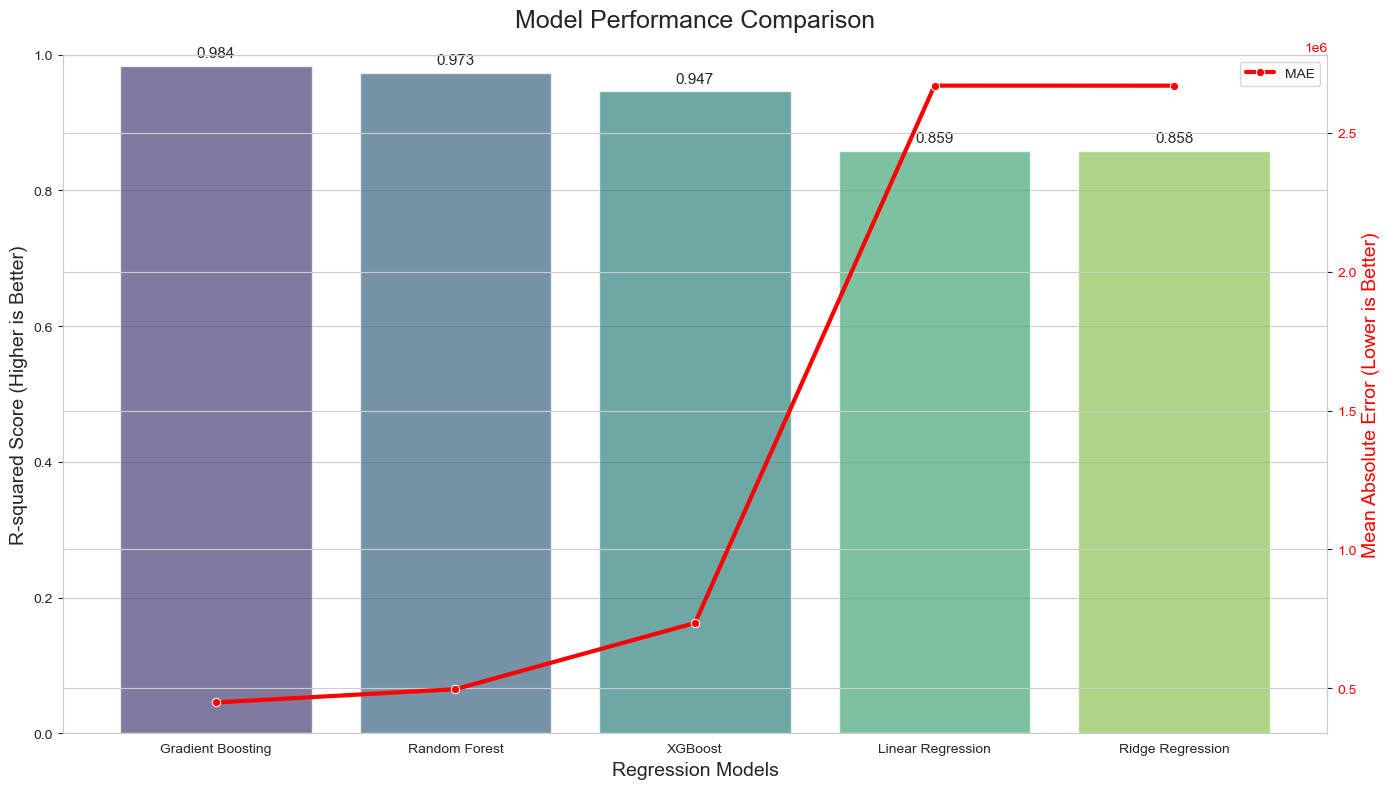

In [8]:
def plot_model_comparison_professional(df_results):
    sns.set_style("whitegrid")
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Bar Plot for R2 Score
    sns.barplot(x='Model', y='R2_Score', data=df_results, ax=ax1, palette='viridis', alpha=0.7)
    ax1.set_title('Model Performance Comparison', fontsize=18, pad=20)
    ax1.set_xlabel('Regression Models', fontsize=14)
    ax1.set_ylabel('R-squared Score (Higher is Better)', fontsize=14)
    ax1.set_ylim(0, 1.0)
    
    # Değerleri barların üzerine yazma
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11)

    # Line Plot for MAE
    ax2 = ax1.twinx()
    sns.lineplot(x='Model', y='MAE', data=df_results, marker='o', color='red', ax=ax2, linewidth=3, label='MAE')
    ax2.set_ylabel('Mean Absolute Error (Lower is Better)', fontsize=14, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.tight_layout()
    # ÖNCE KAYDET
    plt.savefig('model_comparison_results.png', dpi=300, bbox_inches='tight')
    # SONRA GÖSTER
    plt.show()

plot_model_comparison_professional(comparison_df)